In [1]:
import numpy as np 
import matplotlib.pyplot as plt
%pip install -q tensorflow
try:
    import tensorflow as tf
except ModuleNotFoundError:
    %pip install -q tensorflow
    import tensorflow as tf

from tensorflow import keras 
from tensorflow.keras import layers



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
(X_train , y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

In [3]:
print("X_train : ", X_train.shape)
print("y_train : ", y_train.shape)
print("X_test : ", X_test.shape)
print("y_test : ", y_test.shape)

X_train :  (50000, 32, 32, 3)
y_train :  (50000, 1)
X_test :  (10000, 32, 32, 3)
y_test :  (10000, 1)


In [4]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

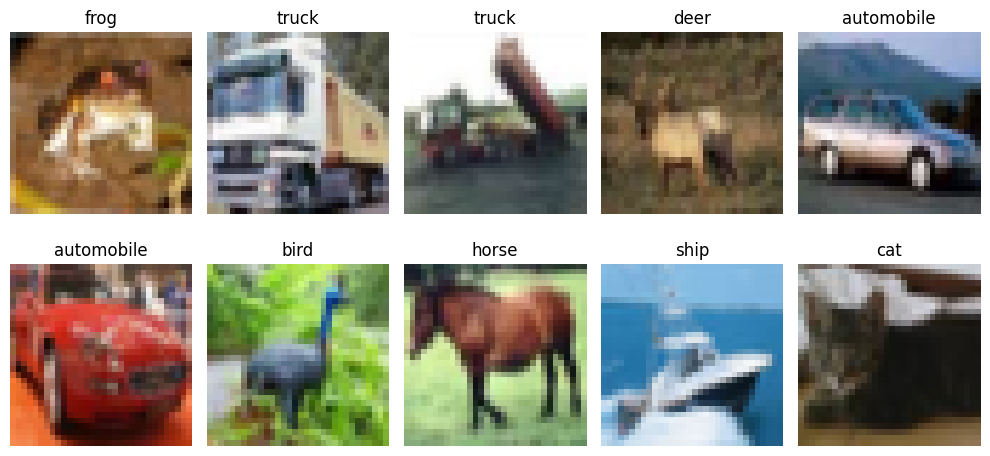

In [5]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
print(X_train[0].shape)

(32, 32, 3)


In [7]:
class_names[2]

'bird'

In [8]:
print("Minimum :", X_train.min())
print("Maximum :", X_train.max())

Minimum : 0
Maximum : 255


In [9]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [10]:
print("Minimum :", X_train.min())
print("Maximum :", X_train.max())
print("Type :", X_train.dtype)

Minimum : 0.0
Maximum : 1.0
Type : float32


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [12]:
print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_val   :", y_val.shape)
print("y_test  :", y_test.shape)

X_train : (45000, 32, 32, 3)
X_val   : (5000, 32, 32, 3)
X_test  : (10000, 32, 32, 3)
y_train : (45000, 1)
y_val   : (5000, 1)
y_test  : (10000, 1)


In [13]:
model = keras.Sequential([
    
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    
    layers.Dense(
        128,
        activation="relu"
    ),
    
    layers.Dense(
        10,
        activation="softmax"
    )
])

c:\Users\ThinkPad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.fit(
    X_train,y_train,epochs=10,batch_size=64, validation_data=(X_val,y_val)
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.4622 - loss: 1.5017 - val_accuracy: 0.5708 - val_loss: 1.2267
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.6032 - loss: 1.1356 - val_accuracy: 0.6272 - val_loss: 1.0688
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.6530 - loss: 0.9923 - val_accuracy: 0.6574 - val_loss: 0.9880
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.6846 - loss: 0.9017 - val_accuracy: 0.6736 - val_loss: 0.9477
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.7114 - loss: 0.8274 - val_accuracy: 0.6962 - val_loss: 0.9069
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.7348 - loss: 0.7641 - val_accuracy: 0.6698 - val_loss: 0.9462
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.7552 - loss: 0.7042 - val_accuracy: 0.7064 - val_loss: 0.8766
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.7752 - loss: 0.6465 - 

In [18]:
history = model.history

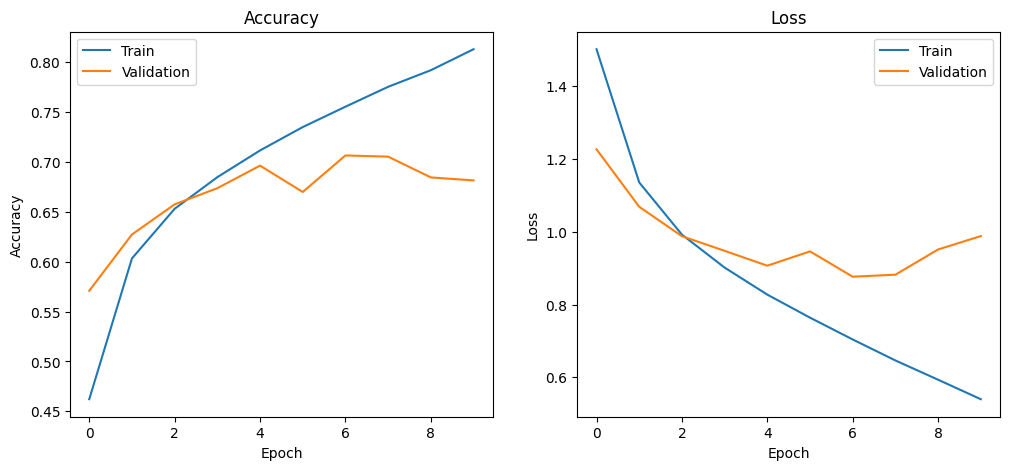

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
history = model.history
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [20]:
test_loss , test_accuracy = model.evaluate(X_test,y_test)
print("testloss:", test_loss)
print("test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6813 - loss: 1.0248
testloss: 1.0248167514801025
test accuracy: 0.6812999844551086


In [21]:
y_pred_proba = model.predict(X_test)

y_pred = np.argmax(y_pred_proba, axis=1)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


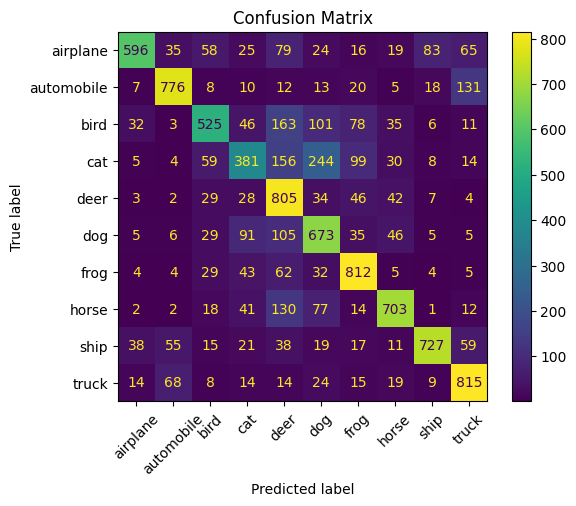

In [22]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [23]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.84      0.60      0.70      1000
  automobile       0.81      0.78      0.79      1000
        bird       0.67      0.53      0.59      1000
         cat       0.54      0.38      0.45      1000
        deer       0.51      0.81      0.63      1000
         dog       0.54      0.67      0.60      1000
        frog       0.70      0.81      0.75      1000
       horse       0.77      0.70      0.73      1000
        ship       0.84      0.73      0.78      1000
       truck       0.73      0.81      0.77      1000

    accuracy                           0.68     10000
   macro avg       0.70      0.68      0.68     10000
weighted avg       0.70      0.68      0.68     10000



In [37]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [25]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.8268 - loss: 0.4948 - val_accuracy: 0.6976 - val_loss: 0.9533
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.8426 - loss: 0.4480 - val_accuracy: 0.7080 - val_loss: 0.9606
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.8590 - loss: 0.4037 - val_accuracy: 0.6970 - val_loss: 1.0098


In [26]:
model_dropout = keras.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

c:\Users\ThinkPad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [28]:
history_dropout = model_dropout.fit(
    X_train , y_train , 
    epochs=20 ,
    batch_size=64 ,
    validation_data=[X_val,y_val],
    callbacks=[early_stop]

)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.3776 - loss: 1.7066 - val_accuracy: 0.4942 - val_loss: 1.4076
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.5002 - loss: 1.3892 - val_accuracy: 0.5770 - val_loss: 1.1910
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.5502 - loss: 1.2631 - val_accuracy: 0.6000 - val_loss: 1.1373
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.5851 - loss: 1.1719 - val_accuracy: 0.6348 - val_loss: 1.0233
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.6109 - loss: 1.1071 - val_accuracy: 0.6648 - val_loss: 0.9873
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.6294 - loss: 1.0596 - val_accuracy: 0.6654 - val_loss: 0.9743
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6447 - loss: 1.0143 - val_accuracy: 0.6468 - val_loss: 0.9875
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.6609 - loss: 0.9702 - 

In [30]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

In [31]:
model_aug = keras.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

c:\Users\ThinkPad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
history_dropout = model_aug.fit(
    X_train , y_train , 
    epochs=20 ,
    batch_size=64 ,
    validation_data=[X_val,y_val],
    callbacks=[early_stop]

)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.4801 - loss: 1.4460 - val_accuracy: 0.5274 - val_loss: 1.3369
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.4952 - loss: 1.4053 - val_accuracy: 0.5596 - val_loss: 1.2190
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.5019 - loss: 1.3836 - val_accuracy: 0.5494 - val_loss: 1.2817
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.5122 - loss: 1.3585 - val_accuracy: 0.5466 - val_loss: 1.2982
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.5247 - loss: 1.3372 - val_accuracy: 0.5380 - val_loss: 1.3477
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.5314 - loss: 1.3226 - val_accuracy: 0.5688 - val_loss: 1.2577


In [39]:
test_loss, test_accuracy = model_aug.evaluate(X_test, y_test)

print("Test loss :", test_loss)
print("Test accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5733 - loss: 1.2046
Test loss : 1.2046235799789429
Test accuracy : 0.5733000040054321


In [40]:
y_pred_proba = model_aug.predict(X_test)

y_pred = np.argmax(y_pred_proba, axis=1)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


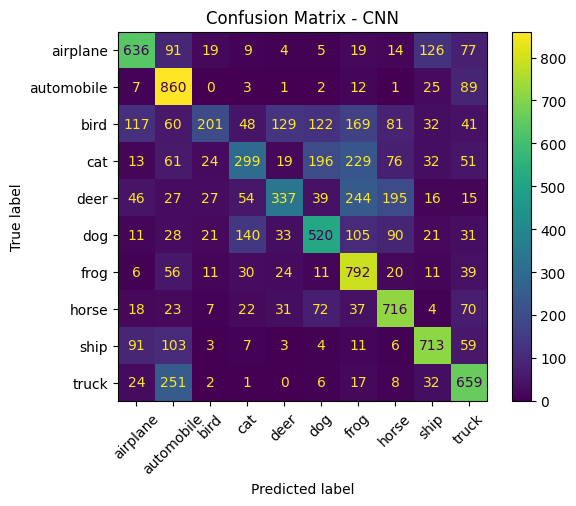

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - CNN")
plt.show()

In [43]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.66      0.64      0.65      1000
  automobile       0.55      0.86      0.67      1000
        bird       0.64      0.20      0.31      1000
         cat       0.49      0.30      0.37      1000
        deer       0.58      0.34      0.43      1000
         dog       0.53      0.52      0.53      1000
        frog       0.48      0.79      0.60      1000
       horse       0.59      0.72      0.65      1000
        ship       0.70      0.71      0.71      1000
       truck       0.58      0.66      0.62      1000

    accuracy                           0.57     10000
   macro avg       0.58      0.57      0.55     10000
weighted avg       0.58      0.57      0.55     10000



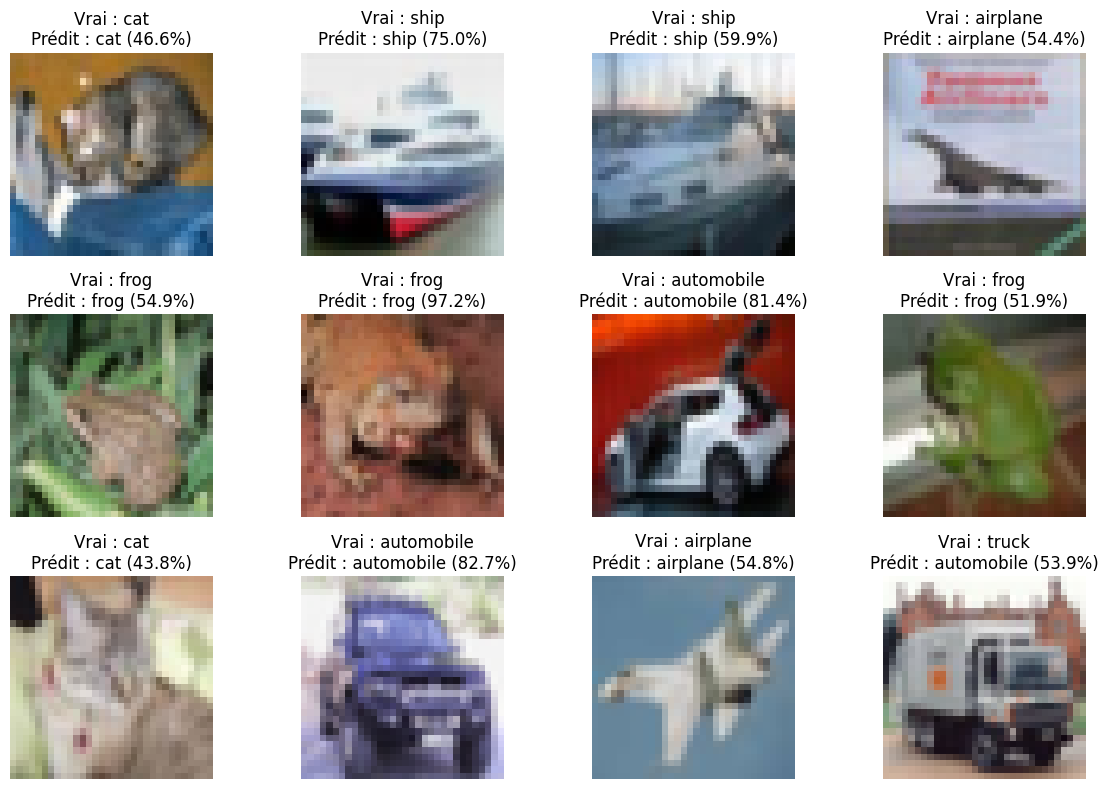

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[i])
    true_label = class_names[y_true[i]]
    predicted_label = class_names[y_pred[i]]
    confidence = np.max(y_pred_proba[i]) * 100
    plt.title(
        f"Vrai : {true_label}\n"
        f"Prédit : {predicted_label} ({confidence:.1f}%)"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
model_aug.save("cifar10_cnn_final.keras")
print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


Dans ce projet, j'ai développé un modèle de Deep Learning basé sur un réseau de neurones convolutif (CNN) pour la classification d'images du dataset CIFAR-10.

Le projet m'a permis de mettre en pratique plusieurs concepts fondamentaux du Deep Learning : normalisation des données, séparation train/validation/test, convolution, filtres, feature maps, pooling, fonctions d'activation, fonction de perte, backpropagation, optimisation avec Adam et classification multi-classes avec Softmax.

J'ai également étudié les problèmes de généralisation et d'overfitting à travers les courbes d'apprentissage, puis appliqué plusieurs techniques de régularisation : Dropout, Data Augmentation et EarlyStopping.

Le modèle final atteint une accuracy de 57.33% sur le test set. L'analyse avec la matrice de confusion, les métriques Precision/Recall/F1 et les prédictions visuelles permet de mieux comprendre ses performances et ses erreurs.

Ce projet constitue une première implémentation complète d'un pipeline de Deep Learning pour la classification d'images.